# Praktikum Machine Learning: Bab 2
## Workflow Machine Learning, CRISP-DM, dan Diagnosis Bias-Variance

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*Notebook ini gw kerjain di Google Colab / Jupyter Notebook.*

## Ringkasan Konsep

**CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) itu kerangka kerja baku buat proyek data mining/ML. Ada **6 fase** yang urut tapi bisa diulang-ulang (*iteratif*):

1. **Business Understanding**: paham dulu tujuan bisnisnya. Masalah apa yang mau diselesaiin, dan kriteria suksesnya apa.
2. **Data Understanding**: ngumpulin dan ngeksplorasi data awal (distribusi, missing value, kualitas data).
3. **Data Preparation**: bersihin dan siapin data: imputasi, encoding, scaling, *sampling*.
4. **Modeling**: milih dan ngelatih model, termasuk tuning hyperparameter.
5. **Evaluation**: ngevaluasi model terhadap tujuan bisnis (bukan cuma liat akurasi).
6. **Deployment**: nerapin model ke lingkungan nyata dan monitor kinerjanya.

**Train / validation / test split:** data dibagi tiga peran. *Train* buat ngelatih, *validation* buat milih/tuning model, *test* buat penilaian akhir yang belum pernah "diliat" model. Kalo test ikut dipake milih model, hasilnya jadi **optimistis palsu** (data leakage).

**Stratified sampling:** teknik pembagian data yang **ngejaga proporsi tiap kelas** di setiap belahan. Penting buat dataset yang nggak seimbang, biar evaluasinya nggak bias gara-gara komposisi kelas yang kebetulan.

**Bias-variance tradeoff:** dua sumber kesalahan model. *Bias* tinggi = model kesederhanaan, gagal nangkep pola (*underfitting*). *Variance* tinggi = model kelewat kompleks, ngafal noise data latih (*overfitting*). Model ideal nyeimbangin keduanya.

**Learning curve** itu alat diagnosisnya: plot skor *train* vs *validasi* terhadap jumlah data latih.
- Keduanya **rendah dan rapet** → *underfitting* (bias tinggi): butuh model yang lebih kompleks / fitur yang lebih bagus.
- **Gap gede** antara train dan validasi → *overfitting* (variance tinggi): sederhanain model atau tambah data.
- **Keduanya tinggi dan gap kecil** → seimbang: model siap dievaluasi di test set.

## 2.12 Implementasi Python

Bagian ini gw ngerjain implementasi dari Modul Machine Learning Bab 2 (bagian 2.12): workflow ML di dataset nyata `breast_cancer` (diagnosis tumor payudara dari 30 fitur pengukuran sel). Alurnya: pembagian data ber-*stratify*, pelatihan Decision Tree, terus diagnosis model lewat learning curve.

dataset yang gw pake: Breast Cancer Wisconsin dari sklearn.datasets (569 pasien, 30 fitur), filenya data/breast_cancer.csv.

### Praktikum 2.1 - Persiapan Library (Modul Bab 2, bagian 2.12)

Bagian ini gw ngerjain Praktikum 2.1 dari Modul Machine Learning Bab 2. Pertama gw import semua library yang dibutuhin dulu. Kalo cell di bawah jalan tanpa error dan muncul tulisan *"Library berhasil dimuat."*, berarti environment udah siap.

In [1]:
# Menjalankan di Google Colab / Jupyter Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.tree import DecisionTreeClassifier

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan outputnya:**
- Nggak ada `ModuleNotFoundError`, artinya `pandas`, `numpy`, `matplotlib`, sama `scikit-learn` semuanya kepasang di environment ini.
- Baris terakhir cuma penanda manual kalo cell ini jalan sampe akhir. Langkah pemanasan sebelum nyentuh data.

### Praktikum 2.2 - Import Dataset (Modul Bab 2, bagian 2.12)

Bagian ini gw ngerjain Praktikum 2.2 dari Modul Machine Learning Bab 2. Dataset `breast_cancer` gw load dari file CSV lokal (`data/breast_cancer.csv`, hasil ekspor dari `sklearn.datasets.load_breast_cancer`), dibaca jadi DataFrame biar gampang dieksplor. Label 0 = *malignant* (tumor ganas), 1 = *benign* (tumor jinak).

In [2]:
# Dataset dibaca dari file CSV lokal (data/breast_cancer.csv) - bisa dipakai offline
# (diekspor dari sklearn.datasets.load_breast_cancer, data real)
df = pd.read_csv('data/breast_cancer.csv')
feature_names = [c for c in df.columns if c not in ('target', 'target_name')]
target_names = ['malignant', 'benign']  # 0 = malignant, 1 = benign
X = df[feature_names]   # 30 fitur pengukuran sel
y = df['target']        # label: 0 = malignant, 1 = benign

print("Ukuran data:", df.shape)
print("Jumlah kolom:", len(df.columns))

print("\nDistribusi kelas (0 = malignant/ganas, 1 = benign/jinak):")
print(np.bincount(y))
prop = np.bincount(y) / len(y)
print(f"\nProporsi kelas 0: {prop[0]:.2%}")
print(f"Proporsi kelas 1: {prop[1]:.2%}")

print("\n6 kolom pertama (dari total 32 kolom, biar muat di halaman):")
df.iloc[:, :6].head()  # tampilkan 6 kolom pertama saja (total 32 kolom)

Ukuran data: (569, 32)
Jumlah kolom: 32

Distribusi kelas (0 = malignant/ganas, 1 = benign/jinak):
[212 357]

Proporsi kelas 0: 37.26%
Proporsi kelas 1: 62.74%

6 kolom pertama (dari total 32 kolom, biar muat di halaman):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness
0,17.99,10.38,122.80,1001.0,0.11840,0.27760
1,20.57,17.77,132.90,1326.0,0.08474,0.07864
2,19.69,21.25,130.00,1203.0,0.10960,0.15990
3,11.42,20.38,77.58,386.1,0.14250,0.28390
4,20.29,14.34,135.10,1297.0,0.10030,0.13280


**Nah, dari output di atas:**
- Ukurannya **(569, 32)**: 569 pasien, 30 fitur pengukuran + kolom `target` (plus `target_name`). Tabel di atas gw tampilin cuma 6 kolom pertama aja (`mean radius`, `mean texture`, dst.) biar muat di halaman. Sisanya 26 kolom lagi isinya sama: angka hasil pengukuran lab juga.
- Distribusi kelas: **212 malignant (37,26%)** vs **357 benign (62,74%)**. Nggak seimbang sempurna, mayoritas jinak. Makanya di langkah berikutnya pembagiannya harus ber-*stratify*, biar proporsi ~37:63 ini kejaga di data latih dan uji.
- Nilai fiturnya angka kontinu hasil pengukuran laboratorium (mis. `mean radius` = 17,99 di baris pertama).

### Praktikum 2.3 - Stratified Split (Modul Bab 2, bagian 2.12)

Bagian ini gw ngerjain Praktikum 2.3 dari Modul Machine Learning Bab 2. Data gw bagi jadi **data latih (80%)** sama **data uji (20%)** pake `stratify=y`, biar proporsi tiap kelas tetep ~37:63 di kedua belahan. Sama persis kayak data aslinya.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Ukuran data latih:", X_train.shape, "| data uji:", X_test.shape)
print("\nProporsi kelas data latih :", np.round(np.bincount(y_train) / len(y_train), 4))
print("Proporsi kelas data uji   :", np.round(np.bincount(y_test) / len(y_test), 4))
print("Proporsi kelas data asli  :", np.round(np.bincount(y) / len(y), 4))

Ukuran data latih: (455, 30) | data uji: (114, 30)

Proporsi kelas data latih : [0.3736 0.6264]
Proporsi kelas data uji   : [0.3684 0.6316]
Proporsi kelas data asli  : [0.3726 0.6274]


**Penjelasan outputnya:**
- Dari 569 data, **455 buat latih** dan **114 buat uji**.
- Proporsi kelas data latih **[0.3736, 0.6264]** dan data uji **[0.3684, 0.6316]**: **hampir identik** sama data asli [0.3726, 0.6274], selisihnya di bawah 0,5 poin persen. Ini bukti `stratify=y` jalan: komposisi kelasnya kejaga.
- `random_state=42` bikin pembagiannya *reproducible*. Tiap eksekusi ulang hasilnya sama persis, jadi praktikum ini bisa direplikasi.

### Praktikum 2.4 - Training & Learning Curve (Modul Bab 2, bagian 2.12)

Bagian ini gw ngerjain Praktikum 2.4 dari Modul Machine Learning Bab 2. Model **Decision Tree** (`max_depth=4`) gw latih, terus `learning_curve` ngitung skor akurasi *train* dan *validasi* (CV 5 lipat) di 8 ukuran data latih yang makin gede: dari 36 sampe 364 data.

In [4]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    model, X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy", shuffle=True, random_state=42)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

print(f"{'Ukuran latih':>12} | {'Train':>7} | {'Validasi':>8}")
print("-" * 34)
for n, tr, va in zip(train_sizes, train_mean, val_mean):
    print(f"{n:>12} | {tr:>7.4f} | {va:>8.4f}")

Ukuran latih |   Train | Validasi
----------------------------------
          36 |  1.0000 |   0.8857
          83 |  0.9976 |   0.9165
         130 |  0.9985 |   0.9231
         176 |  0.9943 |   0.9165
         223 |  0.9946 |   0.9187
         270 |  0.9948 |   0.9187
         317 |  0.9924 |   0.9165
         364 |  0.9912 |   0.9385


**Penjelasan outputnya:**
- Tabelnya nunjukin **8 titik** ukuran data latih: 36 → 83 → 130 → 176 → 223 → 270 → 317 → 364. Notebook ini pake 455 data latih, 80% kepake tiap lipatan CV terus dipotong bertahap sesuai `train_sizes`.
- **Skor train turun** dari 1,0000 (36 data) ke 0,9912 (364 data): makin banyak data, makin susah dihafal sempurna. Tandanya model belajar pola, bukan ngafal.
- **Skor validasi naik** dari 0,8857 (36 data) ke 0,9385 (364 data): data latih yang lebih banyak bikin model **generalisasi lebih baik**. Pola "train turun, validasi naik, gap menyempit" itu ciri khas kurva belajar yang sehat.

### Praktikum 2.5 - Evaluasi (Modul Bab 2, bagian 2.12)

Bagian ini gw ngerjain Praktikum 2.5 dari Modul Machine Learning Bab 2. Gw baca skor di **ukuran data paling gede** (364 data), terus ngitung **gap** train minus validasi buat indikator overfitting.

In [5]:
skor_train = train_mean[-1]
skor_val = val_mean[-1]
gap = skor_train - skor_val

print(f"Skor train (akurasi)    : {skor_train:.4f}")
print(f"Skor validasi (akurasi) : {skor_val:.4f}")
print(f"Gap train - validasi    : {gap:.4f} ({gap:.2%})")

if gap > 0.10:
    print("-> Gap BESAR: indikasi overfitting.")
elif gap > 0.05:
    print("-> Gap sedang: masih wajar, model cukup seimbang.")
else:
    print("-> Gap KECIL: tidak ada overfitting berarti.")

Skor train (akurasi)    : 0.9912
Skor validasi (akurasi) : 0.9385
Gap train - validasi    : 0.0527 (5.27%)
-> Gap sedang: masih wajar, model cukup seimbang.


**Nah, dari output di atas:**
- Di 364 data latih: skor **train = 0,9912**, skor **validasi = 0,9385**, gap = **0,0527** (5,27 poin persen).
- Keduanya **tinggi** (>90%) dan gap-nya cuma ~5 poin. Sesuai kriteria modul: **bias-variance seimbang**, nggak ada tanda overfitting yang serius. Model ini udah layak dievaluasi ke data uji (test set).
- Kalo gap-nya di atas 10 poin, baru deh patut curiga modelnya ngafal. Penanganannya: sederhanain model (kecilin `max_depth`) atau tambah data latih.

### Praktikum 2.6 - Visualisasi Learning Curve (Modul Bab 2, bagian 2.12)

Bagian ini gw ngerjain Praktikum 2.6 dari Modul Machine Learning Bab 2. Hasil tabel Praktikum 2.4 gw gambar jadi kurva, biar pola bias-variance-nya keliatan langsung.

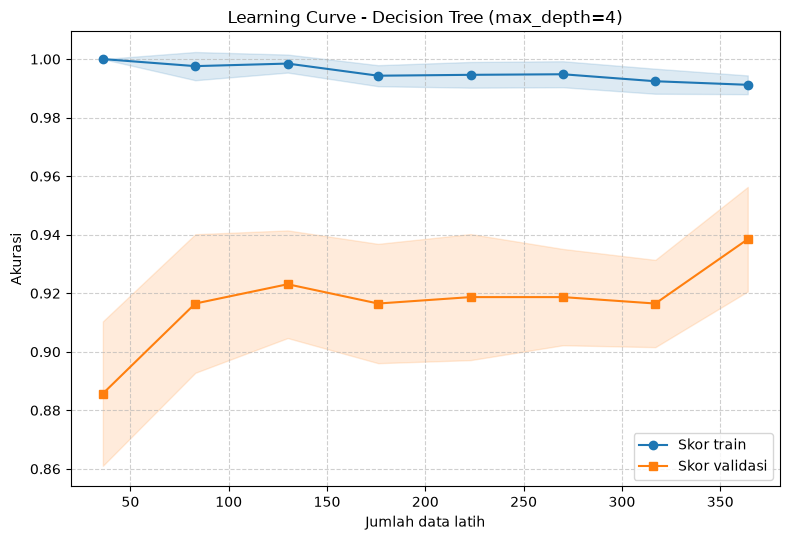

In [6]:
plt.figure(figsize=(8, 5.5))
plt.plot(train_sizes, train_mean, 'o-', label="Skor train", color="tab:blue")
plt.plot(train_sizes, val_mean, 's-', label="Skor validasi", color="tab:orange")
plt.fill_between(train_sizes,
                 train_mean - train_scores.std(axis=1),
                 train_mean + train_scores.std(axis=1),
                 alpha=0.15, color="tab:blue")
plt.fill_between(train_sizes,
                 val_mean - val_scores.std(axis=1),
                 val_mean + val_scores.std(axis=1),
                 alpha=0.15, color="tab:orange")
plt.xlabel("Jumlah data latih")
plt.ylabel("Akurasi")
plt.title("Learning Curve - Decision Tree (max_depth=4)")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- **Kurva biru (train)** mulai di 1,00 terus **turun pelan** ke ~0,99. Model dengan 364 data udah nggak bisa ngafal semuanya, tandanya dia dipaksa belajar pola umum.
- **Kurva oranye (validasi)** mulai di ~0,886 terus **naik** ke ~0,94. Kemampuan generalisasinya membaik seiring data nambah.
- Kedua kurva **menyempit (konvergen)** di ujung kanan, gap ~5 poin, keduanya di atas 0,93. Pola khas model **seimbang**: bukan underfitting (validasi nggak ketinggalan jauh/rendah) dan bukan overfitting (gap nggak melebar).

### 2.12.1 Interpretasi (Modul Bab 2)

Hasil praktikum ini cocok sama panduan modul: **gap kecil + keduanya tinggi = bias-variance seimbang, siap evaluasi test set**. Decision Tree `max_depth=4` di dataset breast cancer ada di titik yang enak: cukup dalem buat nangkep pola (validasi ~94%), cukup dangkal biar nggak ngafal (gap ~5%).

Kalo kebalikannya yang kejadian: gap gede (>10 poin), resep perbaikannya **sederhanain model** (kecilin `max_depth`, gedein `min_samples_leaf`) atau **tambah data latih**. Dua resep ini yang gw uji langsung di bagian eksperimen di bawah.

## Eksperimen (Coba-Coba)

Bagian ini isinya percobaan mandiri gw: ngubah-ngubah kondisi terus ngamatin apa yang kejadian di learning curve. Kayak orang lagi belajar mendiagnosis model.

### Eksperimen 1 - Kompleksitas pohon: `max_depth` = 1 vs 4 vs None

Parameter `max_depth` ngatur seberapa dalem (kompleks) pohon boleh tumbuh. Gw bandingin tiga tingkat: pohon **dangkal banget** (depth=1), **sedang** (depth=4, dari praktikum), dan **tanpa batas** (None).

max_depth |  Train | Validasi |    Gap
--------------------------------------
        1 | 0.9258 |   0.8967 | 0.0291
        4 | 0.9912 |   0.9385 | 0.0527
     None | 1.0000 |   0.9099 | 0.0901


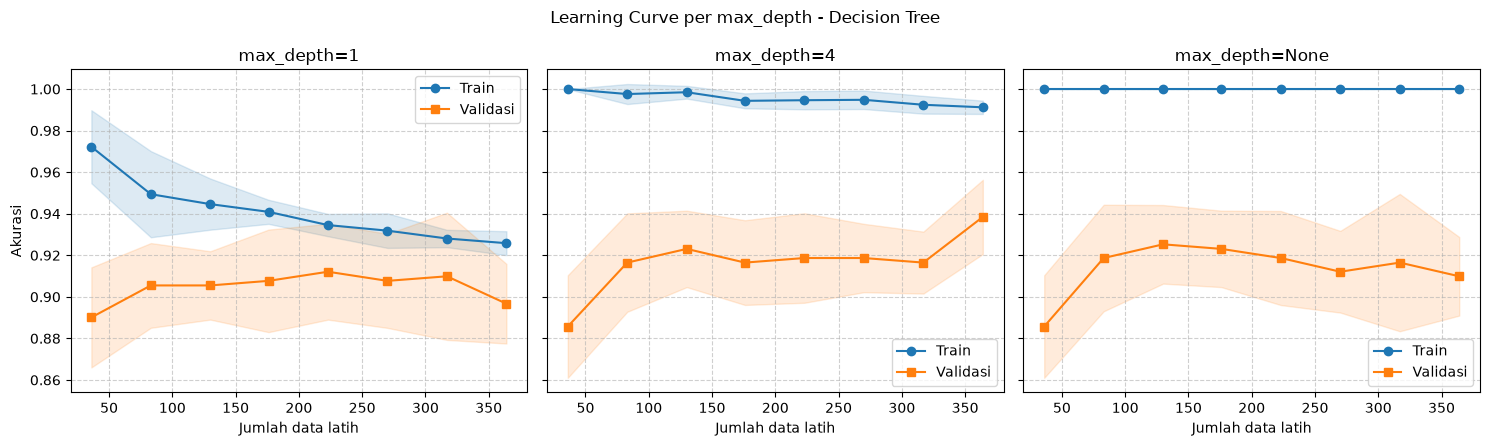

In [7]:
depths = [1, 4, None]
hasil = {}
for md in depths:
    m = DecisionTreeClassifier(max_depth=md, random_state=42)
    ts, tr, va = learning_curve(m, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring="accuracy", shuffle=True, random_state=42)
    hasil[str(md)] = (ts, tr.mean(axis=1), va.mean(axis=1),
                      tr.std(axis=1), va.std(axis=1))

print(f"{'max_depth':>9} | {'Train':>6} | {'Validasi':>8} | {'Gap':>6}")
print("-" * 38)
for md in depths:
    ts, trm, vam, _, _ = hasil[str(md)]
    print(f"{str(md):>9} | {trm[-1]:>6.4f} | {vam[-1]:>8.4f} | "
          f"{trm[-1] - vam[-1]:>6.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, md in zip(axes, depths):
    ts, trm, vam, trs, vas = hasil[str(md)]
    ax.plot(ts, trm, 'o-', label="Train", color="tab:blue")
    ax.plot(ts, vam, 's-', label="Validasi", color="tab:orange")
    ax.fill_between(ts, trm - trs, trm + trs, alpha=0.15, color="tab:blue")
    ax.fill_between(ts, vam - vas, vam + vas, alpha=0.15, color="tab:orange")
    ax.set_title(f"max_depth={md}")
    ax.set_xlabel("Jumlah data latih")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()
axes[0].set_ylabel("Akurasi")
plt.suptitle("Learning Curve per max_depth - Decision Tree")
plt.tight_layout()
plt.show()

**Penjelasan output dan interpretasi:**
- **`max_depth=1` (underfitting / bias tinggi):** train 0,9258, validasi 0,8967, gap cuma 0,0291. Kurvanya **datar dan saling nempel**. Pohon setunggal (*stump*) kesederhanaan: dia bahkan nggak bisa "ngafal" data latih, jadi nambah data nyaris nggak ngebantu (kurva validasi stagnan di ~0,90). Terapi: tambah kompleksitas (naikin depth) atau perbaikin fitur.
- **`max_depth=4` (seimbang):** train 0,9912, validasi 0,9385, gap 0,0527. Kurva validasi naik jelas dari 0,8857 ke 0,9385 seiring data nambah. Pola ideal, *sweet spot* buat dataset ini.
- **`max_depth=None` (overfitting / variance tinggi):** train **1,0000 sempurna di semua ukuran**, validasi cuma 0,9099, gap 0,0901. Kurva train-nya garis datar di angka 1: pohon ngafal semua data latih. Validasi malah **turun** dari 0,9253 (130 data) ke 0,9099 (364 data). Nambah data nggak memperbaiki apa-apa soalnya modelnya udah terlalu fleksibel. Terapi: batasin depth / pruning (dibahas di Bab 5).

Kesimpulannya, ini bukti visual bias-variance tradeoff: kesederhanaan → bias, kebebasan → variance, dan ada titik tengah yang optimal.

### Eksperimen 2 - Apa jadinya kalau split TANPA `stratify`?

Gw ulang pembagian data tanpa `stratify=y`, bandingin proporsinya, terus liat learning curve-nya. Ada bedanya nggak?

In [8]:
# Split TANPA stratify
Xtr_ns, Xte_ns, ytr_ns, yte_ns = train_test_split(
    X, y, test_size=0.2, random_state=42)  # tanpa stratify

print("Proporsi kelas data asli      :", np.round(np.bincount(y) / len(y), 4))
print("DENGAN stratify (data latih)  :",
      np.round(np.bincount(y_train) / len(y_train), 4))
print("TANPA stratify (data latih)   :", np.round(np.bincount(ytr_ns) / len(ytr_ns), 4))
print("TANPA stratify (data uji)     :", np.round(np.bincount(yte_ns) / len(yte_ns), 4))

# Simulasi skenario data KECIL: 60 baris acak TANPA stratify
np.random.seed(3)
idx = np.random.choice(len(y_train), 60, replace=False)
acak = np.bincount(y_train.iloc[idx]) / 60
asli = np.bincount(y) / len(y)
print("\nSub-sampel 60 data acak TANPA stratify ->", np.round(acak, 4))
print(f"   (kelas 0 meleset {abs(acak[0] - asli[0]):.2%} dari proporsi asli "
      f"{asli[0]:.2%} -> {acak[0]:.2%})")

# Learning curve pada split tanpa stratify
m2 = DecisionTreeClassifier(max_depth=4, random_state=42)
ts2, tr2, va2 = learning_curve(m2, Xtr_ns, ytr_ns, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy",
    shuffle=True, random_state=42)
trm2, vam2 = tr2.mean(axis=1), va2.mean(axis=1)
print(f"\nSkor akhir TANPA stratify : train={trm2[-1]:.4f}, "
      f"val={vam2[-1]:.4f}, gap={trm2[-1] - vam2[-1]:.4f}")
print(f"Skor akhir DENGAN stratify : train={train_mean[-1]:.4f}, "
      f"val={val_mean[-1]:.4f}, gap={train_mean[-1] - val_mean[-1]:.4f}")

Proporsi kelas data asli      : [0.3726 0.6274]
DENGAN stratify (data latih)  : [0.3736 0.6264]
TANPA stratify (data latih)   : [0.3714 0.6286]
TANPA stratify (data uji)     : [0.3772 0.6228]

Sub-sampel 60 data acak TANPA stratify -> [0.5 0.5]
   (kelas 0 meleset 12.74% dari proporsi asli 37.26% -> 50.00%)



Skor akhir TANPA stratify : train=0.9885, val=0.9231, gap=0.0654
Skor akhir DENGAN stratify : train=0.9912, val=0.9385, gap=0.0527


**Penjelasan output dan interpretasi:**
- Di dataset segede ini (569 data), split tanpa stratify kebetulan **masih mirip**: proporsi latih [0,3714 / 0,6286] vs asli [0,3726 / 0,6274]. Selisihnya nggak sampe 0,2 poin. Learning curve-nya pun mirip (validasi akhir 0,9231 vs 0,9385 pake stratify; gap 0,0654 vs 0,0527).
- **Tapi itu hoki, bukan jaminan.** Simulasi 60 data acak tanpa stratify ngasilin proporsi **50/50**: meleset **12,74 poin** dari aslinya (37,26% jadi 50%). Di dataset kecil atau kelas yang sangat minoritas, sekali `train_test_split` tanpa stratify bisa bikin lipatan evaluasi nyaris tanpa sampel kelas minoritas. Skor validasinya jadi **acak dan nggak bisa dipercaya**.
- Kesimpulan: `stratify` itu **asuransi murah**. Di data gede efeknya kecil, di data kecil dia nyelametin evaluasi. Biayanya nol (satu argumen), jadi buat klasifikasi selalu pake aja.

### Eksperimen 3 - Decision Tree vs Logistic Regression: siapa yang lebih "lapar data"?

Dua model beda gw bandingin lewat learning curve: Decision Tree (depth=4) vs **Logistic Regression** (pake StandardScaler, soalnya fiturnya beda-beda skala. Scaling bikin optimasinya konvergen).

Decision Tree (depth=4): train=0.9912, val=0.9385, gap=0.0527


Logistic Regression: train=0.9896, val=0.9802, gap=0.0093

Skor validasi pada HANYA 36 data latih:
  Decision Tree      : 0.8857
  Logistic Regression: 0.9538


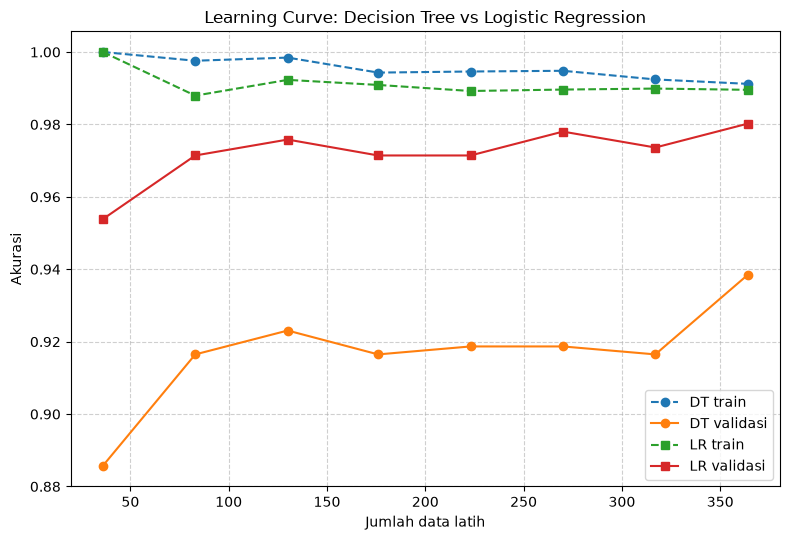

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42))

kurva = {}
for nama, m in [("Decision Tree (depth=4)", dt), ("Logistic Regression", lr)]:
    ts3, tr3, va3 = learning_curve(m, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy",
        shuffle=True, random_state=42)
    trm3, vam3 = tr3.mean(axis=1), va3.mean(axis=1)
    kurva[nama] = (ts3, trm3, vam3)
    print(f"{nama}: train={trm3[-1]:.4f}, val={vam3[-1]:.4f}, "
          f"gap={trm3[-1] - vam3[-1]:.4f}")

print("\nSkor validasi pada HANYA 36 data latih:")
print(f"  Decision Tree      : {kurva['Decision Tree (depth=4)'][2][0]:.4f}")
print(f"  Logistic Regression: {kurva['Logistic Regression'][2][0]:.4f}")

plt.figure(figsize=(8, 5.5))
t_dt, tr_dt, va_dt = kurva["Decision Tree (depth=4)"]
t_lr, tr_lr, va_lr = kurva["Logistic Regression"]
plt.plot(t_dt, tr_dt, 'o--', label="DT train")
plt.plot(t_dt, va_dt, 'o-', label="DT validasi")
plt.plot(t_lr, tr_lr, 's--', label="LR train")
plt.plot(t_lr, va_lr, 's-', label="LR validasi")
plt.xlabel("Jumlah data latih")
plt.ylabel("Akurasi")
plt.title("Learning Curve: Decision Tree vs Logistic Regression")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Penjelasan output dan interpretasi:**
- **Logistic Regression: validasi akhir 0,9802, gap cuma 0,0093.** Kurva train dan validasinya hampir nyatu. Model linear ini bias-nya sedikit lebih tinggi di awal tapi variansnya rendah banget: dia nggak ngafal, jadi skornya stabil.
- **Decision Tree (depth=4): validasi akhir 0,9385, gap 0,0527.** Lebih "rakus": dengan cuma 36 data latih, validasinya cuma **0,8857**, sedangkan LR udah **0,9538**. Pohon butuh lebih banyak data buat nyamain performa. Dia lebih *data-hungry*.
- Kenapa bisa gitu? Decision Tree ngebelah ruang fitur secara rekursif (fleksibel, varians lebih tinggi), sedangkan regresi logistik cuma nyari satu batas linear (kaku tapi stabil). Di dataset ini yang polanya cukup linear, **model sederhana justru menang**: LR lebih akurat DAN lebih stabil.
- Pelajaran praktis: jangan berasumsi model kompleks selalu lebih bagus. Learning curve ngebuktiin secara visual. (Catatan: LR di sini gw pakein `StandardScaler` soalnya tanpa scaling optimasinya gagal konvergen. Preprocessing yang bener itu bagian dari workflow, Bab 4.)

## Studi Kasus - Mendiagnosis Model Nyata dari Learning Curve

Di Modul Bab 2 nggak ada tabel studi kasusnya, jadi gw bikin sendiri versi gw: **hasil learning curve di atas** gw jadiin "pasien". Gw diagnosis kayak dokter baca hasil lab, terus gw kasih resep tindakan.

**Diagnosis model Decision Tree (max_depth=4) di breast cancer:**
1. **Gejala yang kebaca:** skor train 0,9912 dan validasi 0,9385 (gap 5,27 poin). Kurva validasi naik dari 0,8857 ke 0,9385 seiring data nambah; kurva train turun pelan dari 1,0000.
2. **Diagnosis: SEHAT / seimbang.** Bukan underfitting (validasi 93,85% jelas tinggi, kurva validasi masih naik. Modelnya masih "belajar"), bukan overfitting (gap cuma 5 poin, jauh di bawah ambang bahaya ~10 poin).
3. **Resep tindakan:**
   - Lanjut ke **evaluasi test set** (114 data yang belum tersentuh) buat angka final yang jujur.
   - Kalo nanti skor test jauh di bawah validasi, baru curiga dan balik ke fase *Modeling* (CRISP-DM itu iteratif).
   - Opsional: karena kurva validasi masih naik di ujung kanan, **nambah data** kemungkinan masih naikin performa. Sesuai anjuran modul: *"gap kecil, tambah data"* buat kasus overfitting ringan, dan di sini situasinya bahkan lebih bagus.

**Bandingin sama dua "pasien" lain dari eksperimen:**
- *Pasien depth=1*: train 0,9258 / val 0,8967, kurva datar → **underfitting kronis**. Resep: naikin kompleksitas model (depth lebih gede), bukan tambah data. Kurvanya udah stagnan, data baru nggak bakal nolong.
- *Pasien depth=None*: train 1,0000 / val 0,9099, gap 9 poin, validasi turun pas data ditambah → **overfitting**. Resep: sederhanain (batasin depth, pruning di Bab 5) atau tambah data latih.

Ini gunanya learning curve di workflow nyata: **satu gambar nentuin terapi yang beda**. Salah baca gejalanya, salah juga obatnya (mis. nambah data buat model yang underfit cuma buang-buang waktu).

## 2.13 Latihan Praktikum (Modul Bab 2)

### Latihan 1 - Memetakan Proyek Nyata ke CRISP-DM (Modul Bab 2, bagian 2.13)

**Soal:** pilih studi kasus **prediksi churn pelanggan telekomunikasi** (dataset Telco Customer Churn). Tuliskan aktivitas konkret di 6 fase CRISP-DM.

Pertama, gw intip dulu datasetnya biar pemetaannya konkret (bukan karangan). Buat latihan CRISP-DM ini gw intip juga dataset Telco Customer Churn (data/telco-customer-churn.csv).

In [10]:
# Dataset churn dibaca dari file CSV lokal (data/telco-customer-churn.csv)
path_churn = "data/telco-customer-churn.csv"
try:
    churn = pd.read_csv(path_churn)
    print("Shape:", churn.shape)
    print("\nDistribusi Churn (target):")
    print(churn['Churn'].value_counts())
    print((churn['Churn'].value_counts(normalize=True) * 100).round(2))
    kosong = (churn['TotalCharges'].astype(str).str.strip() == '').sum()
    print("\nBaris dengan TotalCharges kosong:", kosong)
    print("\nRata-rata tenure (bulan) per status churn:")
    print(churn.groupby('Churn')['tenure'].mean().round(1))
    print("\nRata-rata MonthlyCharges per status churn:")
    print(churn.groupby('Churn')['MonthlyCharges'].mean().round(1))
    print("\nChurn rate per jenis kontrak:")
    print(pd.crosstab(churn['Contract'], churn['Churn'], normalize='index').round(3))
except FileNotFoundError:
    print("File churn tidak ditemukan di", path_churn)

Shape: (7043, 21)

Distribusi Churn (target):
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Baris dengan TotalCharges kosong: 11

Rata-rata tenure (bulan) per status churn:
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64

Rata-rata MonthlyCharges per status churn:
Churn
No     61.3
Yes    74.4
Name: MonthlyCharges, dtype: float64

Churn rate per jenis kontrak:
Churn              No    Yes
Contract                    
Month-to-month  0.573  0.427
One year        0.887  0.113
Two year        0.972  0.028


**Penjelasan outputnya:**
- Dataset isinya **7.043 pelanggan** dengan **21 kolom**. Targetnya kolom `Churn` (Yes/No).
- Churn cuma **1.869 pelanggan (26,54%)**: kelas minoritas, dataset **nggak seimbang** (mirip breast cancer tadi, tapi lebih timpang). Evaluasi nanti nggak boleh ngandelin akurasi mentah.
- Ada **11 baris** dengan `TotalCharges` kosong (kebaca sebagai string kosong, bukan NaN). Data kotor beneran yang harus dibersihin di fase Data Preparation.
- Sinyal bisnisnya jelas: pelanggan yang churn rata-rata baru **18,0 bulan** berlangganan (vs 37,6 bulan yang bertahan) dan bayarnya **lebih mahal**: tagihan bulanan rata-rata 74,4 vs 61,3. Kontrak *month-to-month* churn-nya **42,7%**, sedangkan kontrak 2 tahun cuma **2,8%**.

**Jawaban: pemetaan ke 6 fase CRISP-DM:**

| Fase | Aktivitas konkret pada proyek churn |
|---|---|
| **1. Business Understanding** | Tujuan: menurunkan churn pelanggan. Kriteria sukses: model bisa mengidentifikasi 80% calon churn dengan presisi yang bisa ditindaklanjuti tim retensi; metrik utama **recall** kelas churn (lebih baik salah alarm daripada kehilangan pelanggan). |
| **2. Data Understanding** | Eksplorasi 7.043 baris × 21 kolom: churn 26,54% (imbalance); 11 baris `TotalCharges` kosong; fitur kandidat kuat: `Contract` (month-to-month churn 42,7%), `tenure` (churn: 18,0 vs 37,6 bulan), `MonthlyCharges` (74,4 vs 61,3), `InternetService` fiber optic churn 41,9%. |
| **3. Data Preparation** | Konversi `TotalCharges` ke numerik (11 baris kosong → NaN → imputasi median); encoding kolom kategorikal (one-hot); scaling fitur numerik; **stratified split** 80/20 menjaga proporsi churn 26,54%; pertimbangkan SMOTE/undersampling untuk imbalance (dibahas Bab 3). |
| **4. Modeling** | Latih baseline Logistic Regression, lalu Decision Tree & Random Forest; tuning via learning curve + validasi silang ber-*stratify*; bandingkan F1/recall kelas churn, bukan sekadar akurasi. |
| **5. Evaluation** | Uji pada test set yang belum tersentuh: cek confusion matrix, precision-recall; validasi dengan tim bisnis - apakah daftar "pelanggan berisiko" masuk akal (mis. didominasi kontrak bulanan + tenure pendek)? Kalau tidak, kembali ke fase 2/3. |
| **6. Deployment** | Model di-*deploy* sebagai skor churn mingguan di dashboard CRM; pelanggan skor tinggi otomatis masuk daftar prioritas tim retensi (penawaran kontrak tahunan/diskon); monitor *data drift* - kalau pola churn berubah, latih ulang. |

### Latihan 2 - Diagnosis Bias-Variance (Praktikum 2.7) (Modul Bab 2, bagian 2.13)

**Soal:** bandingkan learning curve buat `max_depth` = [1, 4, None] di breast cancer; cetak skor train/validasi tiap nilai; tulis diagnosis (underfitting / overfitting / seimbang) buat tiap nilai.

In [11]:
print("=== Praktikum 2.7: diagnosis bias-variance per max_depth ===")
print(f"{'max_depth':>9} | {'Train':>6} | {'Validasi':>8} | {'Gap':>6} | Diagnosis")
print("-" * 62)
for md in [1, 4, None]:
    m = DecisionTreeClassifier(max_depth=md, random_state=42)
    ts, tr, va = learning_curve(m, X_train, y_train, cv=5,
        train_sizes=np.linspace(0.1, 1.0, 8), scoring="accuracy",
        shuffle=True, random_state=42)
    trf, vaf = tr.mean(axis=1)[-1], va.mean(axis=1)[-1]
    gap = trf - vaf
    if trf < 0.95 and vaf < 0.92:
        diag = "UNDERFITTING (bias tinggi)"
    elif gap > 0.08:
        diag = "OVERFITTING (variance tinggi)"
    else:
        diag = "SEIMBANG"
    print(f"{str(md):>9} | {trf:>6.4f} | {vaf:>8.4f} | {gap:>6.4f} | {diag}")

=== Praktikum 2.7: diagnosis bias-variance per max_depth ===
max_depth |  Train | Validasi |    Gap | Diagnosis
--------------------------------------------------------------


        1 | 0.9258 |   0.8967 | 0.0291 | UNDERFITTING (bias tinggi)


        4 | 0.9912 |   0.9385 | 0.0527 | SEIMBANG


     None | 1.0000 |   0.9099 | 0.0901 | OVERFITTING (variance tinggi)


**Jawaban: diagnosis tertulis tiap nilai:**
- **`max_depth=1` → UNDERFITTING (bias tinggi).** Train 0,9258 dan validasi 0,8967: keduanya **rendah** dan gap kecil (0,0291). Pohon setunggal nggak cukup ekspresif buat 30 fitur; dia gagal bahkan di data latihnya sendiri. Terapi: naikin kompleksitas, bukan tambah data.
- **`max_depth=4` → SEIMBANG.** Train 0,9912, validasi 0,9385, gap 0,0527. Kedua skor tinggi dan gap kecil: titik optimal bias-variance buat dataset ini.
- **`max_depth=None` → OVERFITTING (variance tinggi).** Train **1,0000** (ngafal total), validasi 0,9099, gap 0,0901. Modelnya terlalu fleksibel dan ngikutin noise. Terapi: batasin depth atau pruning (Bab 5), atau tambah data latih.

Aturan praktis yang gw pake: kedua skor rendah → underfitting; gap > 8 poin → overfitting; sisanya seimbang. Ambang ini heuristik: yang penting konsisten dan selalu dibaca bareng bentuk kurvanya, bukan satu angka doang.

## Kesimpulan Bab 2

1. **CRISP-DM** ngasih struktur 6 fase (business → data → preparation → modeling → evaluation → deployment) yang iteratif. Kegagalan di fase evaluasi artinya balik ke fase sebelumnya, bukan ngulang dari nol.
2. Pembagian data harus pake **stratified sampling** (`stratify=y`) biar proporsi kelas kejaga. Terbukti ngejaga rasio 37:63 di data latih maupun uji di breast cancer, dan jadi penyelamat di data kecil.
3. **Learning curve** itu alat diagnosis utama: kedua skor rendah dan rapet → underfitting; gap gede → overfitting; keduanya tinggi dan gap kecil → seimbang (model gw: train 0,9912 / val 0,9385 / gap 5,27%).
4. **Bias-variance tradeoff** kebukti empiris: `max_depth=1` underfit (val 0,8967), `max_depth=None` overfit (gap 9 poin), `max_depth=4` seimbang. Kompleksitas model harus disesuaiin sama data.
5. Model sederhana bisa menang: **Logistic Regression** (pake scaling) nyampe validasi 0,9802 dengan gap 0,0093. Ngalahin Decision Tree di dataset ini soalnya lebih stabil dan nggak "lapar data".